# Compare ABC, KDE/GMM, and SBI on the same Local Group pair catalogue

This notebook starts **after pair finding and pair-level filtering**.

The goal is to estimate the same scientific quantity with three approaches:

- **ABC**
- **KDE / GMM**
- **SBI with normalizing flows**

The common target is the conditional distribution

$p(\theta \mid x_{\mathrm{obs}}, S)$

where:

- $\theta$ is the hidden property to infer, for example $\log_{10}(M_{\mathrm{dm,sum}})$
- $x_{\mathrm{obs}}$ is the observed constraint vector, for example $(r, v_r, v_t)$
- $S$ is the analogue-selection pipeline that produced the final catalogue of candidate Local Group pairs

## Important distinction: "the simulation" vs "simulation-based inference"

There are **two different meanings** of "simulation" here:

1. **The cosmological simulation dataset**  
   This is the large halo / galaxy catalogue that defines the problem scope.  
   After pair finding and filtering, it becomes the empirical pool of Local Group analogue pairs.

2. **Simulation-based inference (SBI)**  
   In SBI papers, a "simulator" often means a forward model that maps parameters $\theta$ to observables $x$.

In this project, we are mostly using the **existing pair catalogue** as an empirical sample from the joint distribution $p(\theta, x \mid S)$.
So this notebook is best thought of as:

- build a pair catalogue from the cosmological simulation
- choose features $X$ and an observed system $x_{\mathrm{obs}}$
- compare different methods for estimating $p(\theta \mid x_{\mathrm{obs}}, S)$

## What this notebook gives you

- one place to configure $x_{\mathrm{obs}}$ and the active features
- one table comparing posterior summaries across methods
- one figure comparing the posterior over $\theta$
- feature-space plots showing how the methods react to the same observation
- SBI calibration plots

## 1) Imports and helper modules

This notebook assumes that the following variables already exist in memory from the earlier pair-finding workflow:

- `sample`
- `pipeline`
- optional: `sub`

If they are not present yet, run the earlier data-loading and pair-finding cells first.

In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import illustris_python as il


# Make helper modules importable from several likely locations.
candidate_paths = [
    Path.cwd(),
    Path.cwd().parent / "scripts",
    Path("/mnt/data"),
]
for p in candidate_paths:
    if p.exists():
        sys.path.insert(0, str(p))

# ABC helpers
try:
    from lg_abc import build_pair_catalog, run_abc_catalog, summarize_posterior
except Exception:
    from lg_abc_updated import build_pair_catalog, run_abc_catalog, summarize_posterior

# KDE / GMM helpers
from lg_gmm_kde import (
    prepare_density_problem,
    run_kde_conditioning,
    fit_joint_gmm,
    condition_gmm,
    posterior_predictive_from_weights,
    weighted_gaussian_kde_1d,
)

# SBI helpers
from lg_sbi import (
    fit_catalog_npe,
    infer_with_npe,
    plot_sbc_rank_hist,
    plot_expected_coverage,
)

import lg_analogues as lg

# Data paths and fields
basePath = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
snap = 99

subhalo_fields = [
    "SubhaloPos",
    "SubhaloVel",
    "SubhaloMassType",
    "SubhaloSFRinRad",
    "SubhaloFlag",
    "SubhaloGrNr",
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
header_consts = lg.load_header_constants(basePath, snap)
h = header_consts["h"]
box_ckpch = header_consts["box_ckpch"]

print("Loaded subhalos:", sub["count"])
print("h:", h, "box_ckpch:", box_ckpch)

# Selection S: central + largest satellite in stellar-mass window
mstar_min = 2e10
mstar_max = 5e11

sample = lg.select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=mstar_min,
    mstar_max=mstar_max,
)

print("Selected objects:", sample.keep_idx.size)

# Pair finding in separation window
r_min_kpc = 500.0
r_max_kpc = 1000.0

pair_set = lg.find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,
    box_ckpch=box_ckpch,
    r_min_kpc=r_min_kpc,
    r_max_kpc=r_max_kpc,
)

print("Pairs before filtering:", pair_set.i.size)
print("same-host pairs:", int(np.sum(pair_set.same_host)))
print("different-host pairs:", int(np.sum(~pair_set.same_host)))

# Pipeline filters: isolation (no third object with M* >= x * max(M*_pair) in relevant FoF group(s))
pipeline = lg.AnaloguePipeline(pair_set)

isolation_x = 1.5
iso_mask = lg.isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pair_i=pipeline.pairs.i,
    pair_j=pipeline.pairs.j,
    sample_grnr=sample.grnr,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    x=isolation_x,
)
pipeline.apply_filter(f"isolation_x{isolation_x}", iso_mask)

pipeline.print_cutflow()
cutflow = pipeline.get_cutflow()
#cutflow


# Basic check that the notebook is being run after pair finding.
required_names = ["sample", "pipeline"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required objects in memory: "
        + ", ".join(missing)
        + ". Run the earlier pair-finding notebook cells first."
    )

print("Imports loaded successfully.")

Loaded subhalos: 14485709
h: 0.6774 box_ckpch: 205000.0
Selected objects: 45392
Pairs before filtering: 2655
same-host pairs: 2084
different-host pairs: 571
initial: 2655 pairs remaining
isolation_x1.5: 2601 pairs remaining
Imports loaded successfully.


## 2) User-editable configuration

This is the main cell to edit.

### How to change the observed system

- `ACTIVE_FEATURES` chooses which features are used in $X$ and in $x_{\mathrm{obs}}$
- `FEATURE_INFO[name]["obs"]` is the observed value for each feature
- `FEATURE_INFO[name]["sigma"]` is the ABC / KDE scale for that feature

The order of `ACTIVE_FEATURES` is the order used in the feature matrix $X$ and the observation vector $x_{\mathrm{obs}}$.

### Important meaning of `sigma`

Here, `sigma` is **not** the cosmological simulation and **not** an SBI parameter.

It is the feature scale used by **ABC** and **KDE** to define closeness to $x_{\mathrm{obs}}$:

$d_i = \sqrt{\sum_j \left(\frac{x_{ij} - x_{\mathrm{obs},j}}{\sigma_j}\right)^2}$

- smaller `sigma` means stricter matching
- larger `sigma` means looser matching

SBI does **not** use this ABC-style `sigma` inside the posterior model.

In [7]:
# ----------------------------
# Feature metadata
# ----------------------------

FEATURE_INFO = {
    "r_kpc": {
        "obs": 770.0,
        "sigma": 50.0,
        "label": "Pair separation $r$ [kpc]",
        "description": "Current MW-M31 separation proxy.",
    },
    "v_r": {
        "obs": -109.0,
        "sigma": 20.0,
        "label": "Radial velocity $v_r$ [km/s]",
        "description": "Relative radial velocity of the pair.",
    },
    "v_t": {
        "obs": 17.0,
        "sigma": 30.0,
        "label": "Tangential velocity $v_t$ [km/s]",
        "description": "Relative tangential velocity of the pair.",
    },
    # Optional examples. Enable only if these columns exist in the catalogue.
    "same_host": {
        "obs": 0.0,
        "sigma": 0.5,
        "label": "Same-host flag",
        "description": "Whether both objects belong to the same host halo.",
    },
    "mstar_big": {
        "obs": 5e10,
        "sigma": 1e10,
        "label": "Larger stellar mass",
        "description": "Stellar mass of the more massive member.",
    },
    "mstar_small": {
        "obs": 4e10,
        "sigma": 1e10,
        "label": "Smaller stellar mass",
        "description": "Stellar mass of the less massive member.",
    },
}

# Choose the active features for the comparison.
ACTIVE_FEATURES = ["r_kpc", "v_r", "v_t"]

# Feature transforms, if needed.
LOG10_FEATURES = set()

# Choose the hidden quantity to infer.
TARGET = "mdm_sum"
TARGET_LOG10 = True

# ABC config
ABC_ACCEPT_FRAC = 0.05
ABC_KERNEL_BANDWIDTH = 1.0

# GMM config
GMM_COMPONENTS = "bic"  # can also be an integer like 2, 3, 4, ...
GMM_RANDOM_STATE = 0

# SBI config
SBI_CONFIG = {
    "density_model": "maf",
    "hidden_features": 64,
    "num_transforms": 5,
    "training_batch_size": 128,
    "learning_rate": 5e-4,
    "validation_fraction": 0.1,
    "calibration_fraction": 0.2,
    "stop_after_epochs": 30,
    "max_num_epochs": 300,
    "random_state": 0,
    "show_train_summary": False,
}

def build_x_obs_and_sigma(feature_info, active_features):
    x_obs = np.array([feature_info[name]["obs"] for name in active_features], dtype=float)
    sigma = np.array([feature_info[name]["sigma"] for name in active_features], dtype=float)
    return x_obs, sigma

x_obs, sigma = build_x_obs_and_sigma(FEATURE_INFO, ACTIVE_FEATURES)

config_df = pd.DataFrame([
    {
        "feature": name,
        "observed_value": FEATURE_INFO[name]["obs"],
        "sigma_for_ABC_KDE": FEATURE_INFO[name]["sigma"],
        "label": FEATURE_INFO[name]["label"],
        "description": FEATURE_INFO[name]["description"],
    }
    for name in ACTIVE_FEATURES
])

display(config_df)
print("TARGET =", TARGET, "| TARGET_LOG10 =", TARGET_LOG10)
print("x_obs =", x_obs)
print("sigma =", sigma)

,feature,observed_value,sigma_for_ABC_KDE,label,description
0,r_kpc,770.0,50.0,Pair separation $r$ [kpc],Current MW-M31 separation proxy.
1,v_r,-109.0,20.0,Radial velocity $v_r$ [km/s],Relative radial velocity of the pair.
2,v_t,17.0,30.0,Tangential velocity $v_t$ [km/s],Relative tangential velocity of the pair.


TARGET = mdm_sum | TARGET_LOG10 = True
x_obs = [ 770. -109.   17.]
sigma = [50. 20. 30.]


## 3) Build the final analogue catalogue and extract $X$ and $\theta$

At this point, each row in the final catalogue is one simulated Local Group analogue pair.

That row contains both:

- a feature vector $x_i$
- a target value $\theta_i$

So the catalogue can be treated as an empirical sample from the joint distribution $p(\theta, x \mid S)$.

In [8]:
# If `sub` is not available in memory, the helper still works without SFR columns.
sub_arg = globals().get("sub", None)

catalog = build_pair_catalog(
    sample=sample,
    pairs=pipeline.pairs,
    sub=sub_arg,
    sfr_field="SubhaloSFRinRad" if sub_arg is not None else None,
)

problem = prepare_density_problem(
    catalog=catalog,
    features=ACTIVE_FEATURES,
    target=TARGET,
    log10_features=LOG10_FEATURES,
    target_log10=TARGET_LOG10,
)

X = problem["X"]
theta = problem["theta"]
feature_names = problem["feature_names"]
target_name = problem["target_name"]

print("Pairs after cuts:", X.shape[0])
print("Number of active features:", X.shape[1])
print("Dropped non-finite rows:", problem["dropped_rows"])

prior_summary = summarize_posterior(theta)
display(pd.DataFrame([prior_summary], index=["all pairs after $S$"]))

Pairs after cuts: 2601
Number of active features: 3
Dropped non-finite rows: 0


,mean,median,q16,q84
all pairs after $S$,12.869573,12.79938,12.481337,13.305574


## 4) Sanity plots before inference

These plots answer two basic questions:

1. Is the observed system inside the support of the analogue catalogue?
2. Which features already look common or unusual before conditioning?

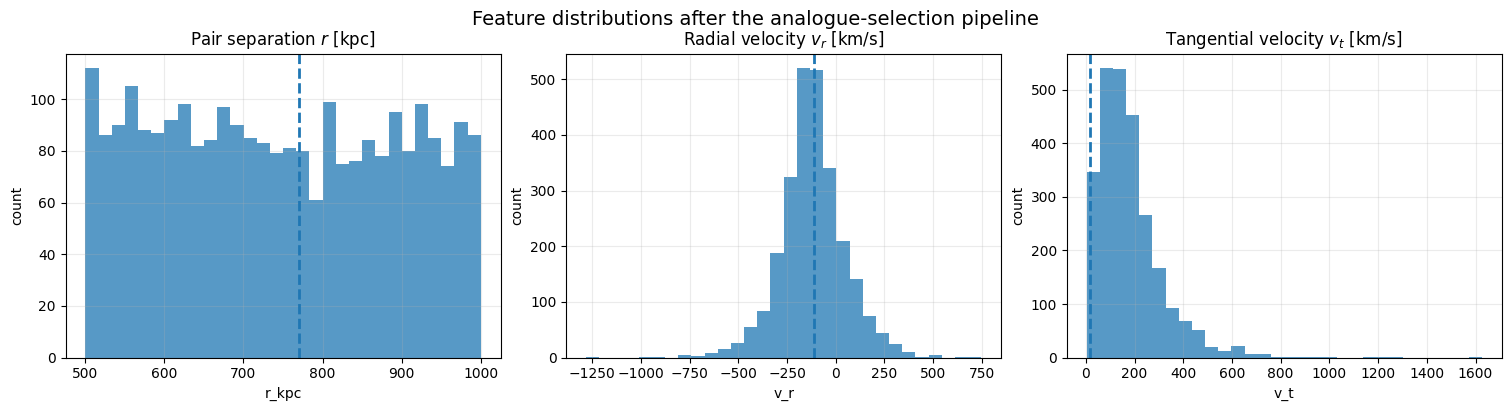

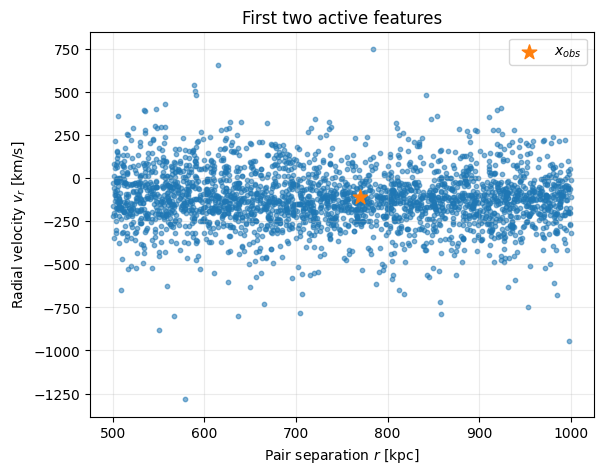

In [9]:
n_features = len(ACTIVE_FEATURES)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 3.8), constrained_layout=True)
if n_features == 1:
    axes = [axes]

for j, name in enumerate(ACTIVE_FEATURES):
    ax = axes[j]
    ax.hist(X[:, j], bins=30, alpha=0.75)
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    ax.set_title(FEATURE_INFO[name]["label"])
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    ax.grid(alpha=0.25)

fig.suptitle("Feature distributions after the analogue-selection pipeline", y=1.04, fontsize=14)
plt.show()

if len(ACTIVE_FEATURES) >= 2:
    fig, ax = plt.subplots(figsize=(6.5, 5.0))
    ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.55)
    ax.scatter(x_obs[0], x_obs[1], s=120, marker="*", label="$x_{obs}$")
    ax.set_xlabel(FEATURE_INFO[ACTIVE_FEATURES[0]]["label"])
    ax.set_ylabel(FEATURE_INFO[ACTIVE_FEATURES[1]]["label"])
    ax.set_title("First two active features")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

## 5) Run ABC, KDE, GMM, and SBI on the same $(X, \theta, x_{\mathrm{obs}})$

A useful way to think about the methods:

- **ABC rejection**: keep the pairs closest to $x_{\mathrm{obs}}$
- **ABC kernel**: smoothly weight pairs by closeness
- **KDE conditioning**: almost the same idea as kernel ABC, phrased as density estimation
- **GMM**: fit a smooth parametric model to the joint distribution $[\theta, X]$
- **SBI / NPE**: train a neural density estimator for $q_\phi(\theta \mid x)$

Do not be surprised if **kernel ABC** and **KDE** look very similar.  
With the same bandwidth choice, they are intentionally close in spirit.

In [10]:
# ABC
abc_result = run_abc_catalog(
    X=X,
    theta=theta,
    x_obs=x_obs,
    sigma=sigma,
    accept_frac=ABC_ACCEPT_FRAC,
    kernel_bandwidth=ABC_KERNEL_BANDWIDTH,
)

print("ABC accept rate:", abc_result["accept_rate"])
print("ABC rejection summary:")
print(abc_result["summary_rejection"])
print("ABC kernel summary:")
print(abc_result["summary_kernel"])

# KDE
kde_result = run_kde_conditioning(
    X=X,
    theta=theta,
    x_obs=x_obs,
    bandwidth=sigma,
)

print()
print("KDE summary:")
print(kde_result["summary"])

# GMM
gmm_fit = fit_joint_gmm(
    X=X,
    theta=theta,
    n_components=GMM_COMPONENTS,
    random_state=GMM_RANDOM_STATE,
)
gmm_result = condition_gmm(
    gmm_fit,
    x_obs=x_obs,
    n_samples=20_000,
    random_state=GMM_RANDOM_STATE,
)

print()
print("GMM summary:")
print(gmm_result["summary"])

# SBI
# If needed in a fresh environment, uncomment:
# %pip install sbi

fit = fit_catalog_npe(
    X=X,
    theta=theta,
    x_obs=x_obs,
    feature_names=feature_names,
    target_name=target_name,
    **SBI_CONFIG,
)

sbi_result = infer_with_npe(
    fit,
    x_obs=x_obs,
    num_samples=20_000,
    random_state=SBI_CONFIG["random_state"],
    ppc_draws=500,
    ppc_neighbors=25,
)

print()
print("SBI summary:")
print(sbi_result["summary"])

ABC accept rate: 0.050365244136870435
ABC rejection summary:
{'mean': 12.558323849044358, 'median': 12.504323511880862, 'q16': 12.37038867567865, 'q84': 12.640507890143033}
ABC kernel summary:
{'mean': 12.520913276048553, 'median': 12.472528060017112, 'q16': 12.369241135213237, 'q84': 12.609286523989482, 'ess': 55.29047533914513}

KDE summary:
{'mean': 12.520913276048555, 'median': 12.472528060017112, 'q16': 12.369241135213237, 'q84': 12.609286523989482, 'ess': 55.290475339145125}

GMM summary:
{'mean': 12.481262520205695, 'median': 12.454290964144953, 'q16': 12.342617283925696, 'q84': 12.581967312596008}


/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/sbi/neural_nets/net_builders/flow.py:149: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 81 epochs.

100%|██████████| 20000/20000 [00:00<00:00, 195197.39it/s]



SBI summary:
{'mean': 12.495787291574478, 'median': 12.495768070220947, 'q16': 12.2694234085083, 'q84': 12.721512908935546}


## 6) Build a side-by-side comparison table

This is the most compact summary of the scientific result.

If `TARGET_LOG10 = True`, the rightmost columns convert the posterior summary back to linear scale, for example from $\log_{10}(M)$ to $M$.

In [11]:
def weighted_percentile_of_obs(values, weights, obs):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if values.ndim != 1 or weights.ndim != 1 or values.size != weights.size:
        raise ValueError("values and weights must be matching 1D arrays")
    total = weights.sum()
    if total <= 0:
        return np.nan
    wn = weights / total
    return float(wn[values <= obs].sum())

def uniform_weights_from_mask(mask):
    mask = np.asarray(mask, dtype=bool)
    w = mask.astype(float)
    total = w.sum()
    if total > 0:
        w /= total
    return w

summary_rows = []

summary_rows.append({
    "method": "all pairs after $S$",
    **prior_summary,
})

if abc_result["summary_rejection"] is not None:
    summary_rows.append({
        "method": "ABC rejection",
        **abc_result["summary_rejection"],
        "accept_rate": abc_result["accept_rate"],
    })

summary_rows.append({
    "method": "ABC kernel",
    **abc_result["summary_kernel"],
    "ess": abc_result["ess"],
})

summary_rows.append({
    "method": "KDE",
    **kde_result["summary"],
})

summary_rows.append({
    "method": "GMM",
    **gmm_result["summary"],
})

summary_rows.append({
    "method": "SBI",
    **sbi_result["summary"],
})

summary_df = pd.DataFrame(summary_rows)

if TARGET_LOG10:
    for col in ["median", "q16", "q84"]:
        if col in summary_df.columns:
            summary_df[f"{col}_linear"] = summary_df[col].apply(
                lambda v: np.nan if pd.isna(v) else 10 ** float(v)
            )

display(summary_df)

,method,mean,median,q16,q84,accept_rate,ess,median_linear,q16_linear,q84_linear
0,all pairs after $S$,12.869573,12.799380,12.481337,13.305574,NaN,NaN,6.300566e+12,3.029263e+12,2.021034e+13
1,ABC rejection,12.558324,12.504324,12.370389,12.640508,0.050365,NaN,3.193916e+12,2.346328e+12,4.370266e+12
2,ABC kernel,12.520913,12.472528,12.369241,12.609287,NaN,55.290475,2.968439e+12,2.340136e+12,4.067116e+12
3,KDE,12.520913,12.472528,12.369241,12.609287,NaN,55.290475,2.968439e+12,2.340136e+12,4.067116e+12
4,GMM,12.481263,12.454291,12.342617,12.581967,NaN,NaN,2.846367e+12,2.200986e+12,3.819155e+12
5,SBI,12.495787,12.495768,12.269423,12.721513,NaN,NaN,3.131613e+12,1.859617e+12,5.266389e+12


## 7) Compare the posterior over $\theta$

This figure answers the main scientific question:

How much do the methods agree on the inferred distribution of the hidden quantity?

Interpretation guide:

- if the curves largely overlap, the scientific answer is robust to method choice
- if the methods disagree strongly, that is a signal to inspect bandwidths, GMM flexibility, SBI calibration, or feature choices

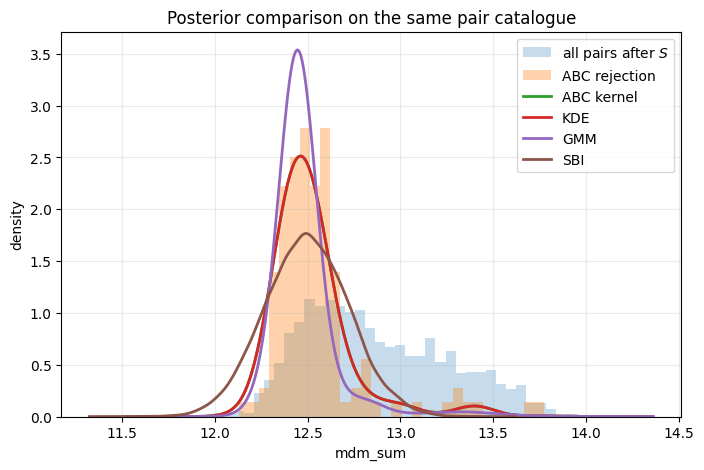

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

# Prior-like baseline
ax.hist(theta, bins=40, density=True, alpha=0.25, label="all pairs after $S$")

# ABC rejection
if abc_result["theta_accepted"].size > 0:
    ax.hist(
        abc_result["theta_accepted"],
        bins=30,
        density=True,
        alpha=0.35,
        label="ABC rejection",
    )

# ABC kernel as a smooth line
grid_abc_kernel, dens_abc_kernel = weighted_gaussian_kde_1d(theta, weights=abc_result["weights"])
ax.plot(grid_abc_kernel, dens_abc_kernel, linewidth=2, label="ABC kernel")

# KDE
ax.plot(kde_result["theta_grid"], kde_result["theta_density"], linewidth=2, label="KDE")

# GMM
ax.plot(gmm_result["theta_grid"], gmm_result["theta_density"], linewidth=2, label="GMM")

# SBI as a smooth line for readability
grid_sbi, dens_sbi = weighted_gaussian_kde_1d(sbi_result["samples"])
ax.plot(grid_sbi, dens_sbi, linewidth=2, label="SBI")

ax.set_xlabel(target_name)
ax.set_ylabel("density")
ax.set_title("Posterior comparison on the same pair catalogue")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 8) Feature-space comparison

These plots show how the methods respond to the same observed system in feature space.

- **ABC rejection** shows only the accepted pairs
- **KDE** shows a weighted empirical posterior over pairs
- **SBI** shows an approximate posterior predictive in feature space

There is no direct pair-weight plot for **GMM** because GMM is modeling a smooth conditional density over $\theta$, not assigning explicit weights to the original catalogue rows.

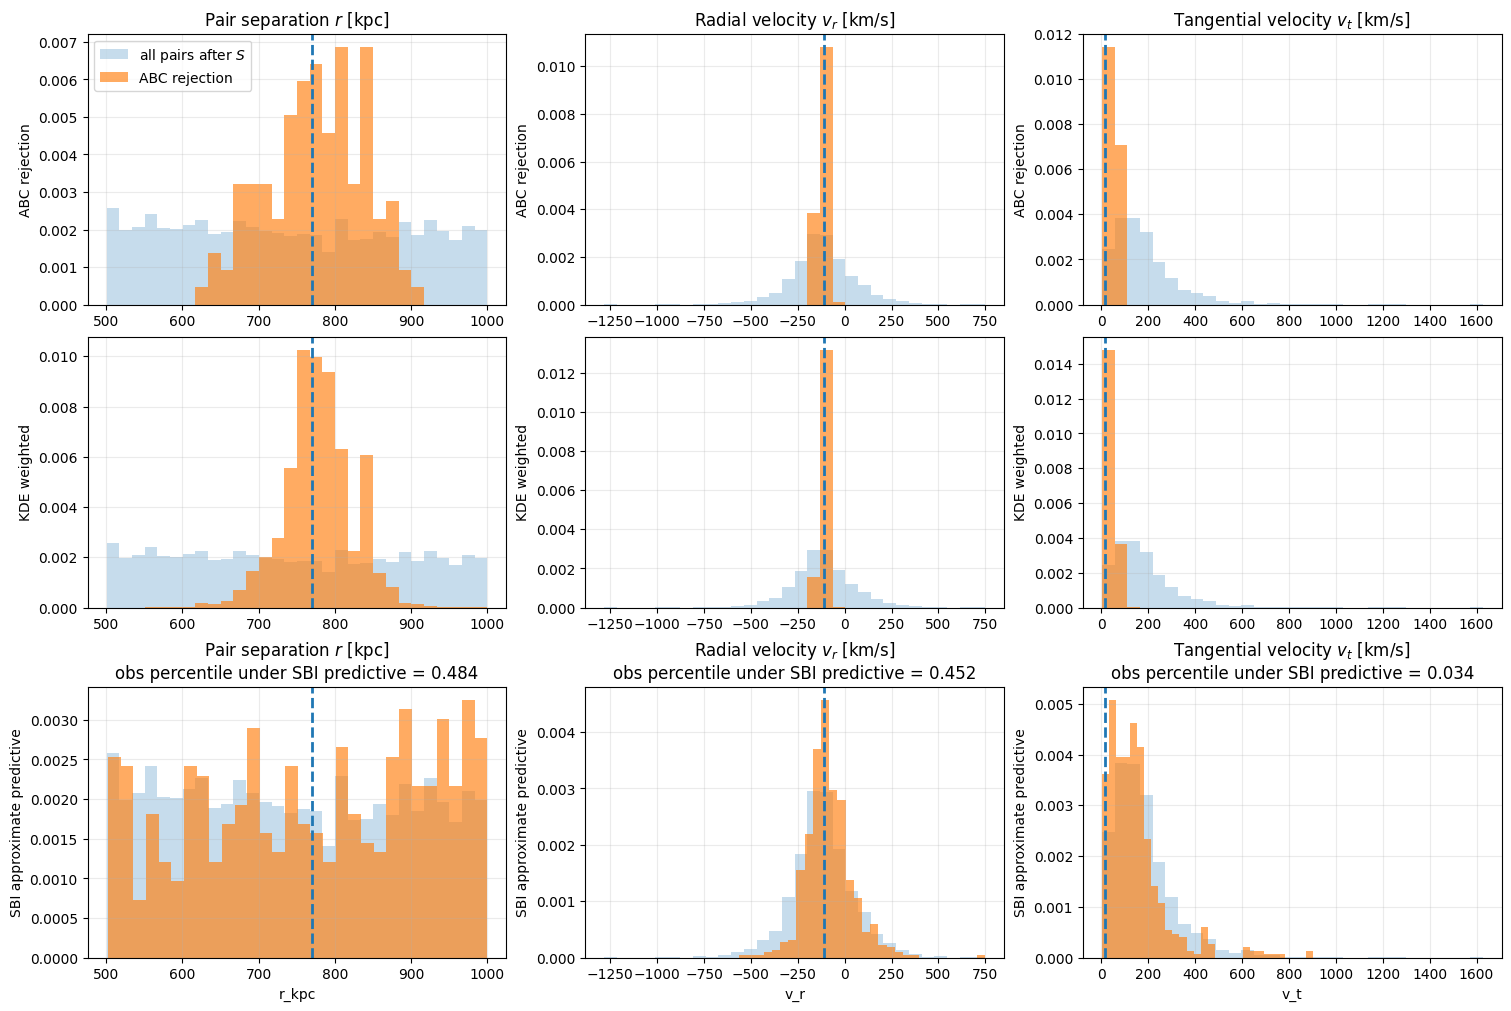

In [13]:
def weighted_hist(ax, values, weights=None, bins=30, alpha=0.5, label=None):
    ax.hist(values, bins=bins, weights=weights, density=True, alpha=alpha, label=label)

abc_rej_weights = uniform_weights_from_mask(abc_result["accept_mask"])
x_pred_sbi = sbi_result["x_predictive_samples"]

fig, axes = plt.subplots(
    3,
    len(ACTIVE_FEATURES),
    figsize=(5 * len(ACTIVE_FEATURES), 10),
    constrained_layout=True,
)
if len(ACTIVE_FEATURES) == 1:
    axes = np.array(axes).reshape(3, 1)

row_titles = ["ABC rejection", "KDE weighted", "SBI approximate predictive"]

for j, name in enumerate(ACTIVE_FEATURES):
    base_values = X[:, j]

    # Row 1: ABC rejection
    ax = axes[0, j]
    weighted_hist(ax, base_values, bins=30, alpha=0.25, label="all pairs after $S$")
    weighted_hist(ax, base_values, weights=abc_rej_weights, bins=30, alpha=0.65, label="ABC rejection")
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    ax.set_title(FEATURE_INFO[name]["label"])
    ax.set_ylabel(row_titles[0])
    ax.grid(alpha=0.25)

    # Row 2: KDE
    ax = axes[1, j]
    weighted_hist(ax, base_values, bins=30, alpha=0.25, label="all pairs after $S$")
    weighted_hist(ax, base_values, weights=kde_result["weights"], bins=30, alpha=0.65, label="KDE weighted")
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    ax.set_ylabel(row_titles[1])
    ax.grid(alpha=0.25)

    # Row 3: SBI approximate predictive
    ax = axes[2, j]
    weighted_hist(ax, base_values, bins=30, alpha=0.25, label="all pairs after $S$")
    weighted_hist(ax, x_pred_sbi[:, j], bins=30, alpha=0.65, label="SBI predictive")
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    pct = sbi_result["x_obs_predictive_percentile"][name]
    ax.set_ylabel(row_titles[2])
    ax.set_xlabel(name)
    ax.set_title(f"{FEATURE_INFO[name]['label']}\nobs percentile under SBI predictive = {pct:.3f}")
    ax.grid(alpha=0.25)

axes[0, 0].legend()
plt.show()

## 9) Support check and interpretation helpers

The support check answers:

- is $x_{\mathrm{obs}}$ inside the range of the training catalogue?
- does the observation have a nearby neighbour in feature space?

This matters most for SBI, because a posterior is much easier to trust when it is not an extrapolation problem.

In [14]:
support = sbi_result["support_check"]

support_df = pd.DataFrame({
    "feature": feature_names,
    "obs": x_obs,
    "feature_min": support["feature_min"],
    "feature_max": support["feature_max"],
    "outside_range": support["outside_range"],
    "nearest_feature_value": support["nearest_x"],
})

display(support_df)

print("n_outside =", support["n_outside"])
print("nearest_distance =", support["nearest_distance"])
print("nearest_index =", support["nearest_index"])

,feature,obs,feature_min,feature_max,outside_range,nearest_feature_value
0,r_kpc,770.0,500.600281,999.99115,False,767.437805
1,v_r,-109.0,-1282.880737,748.37384,False,-109.744781
2,v_t,17.0,3.006503,1626.08020,False,21.939215


n_outside = 0
nearest_distance = 0.03977964523997105
nearest_index = 1623


## 10) SBI calibration plots

These are practical diagnostics for the neural posterior estimator.

- **SBC rank histogram**: should look roughly uniform if the posterior is calibrated
- **Expected coverage**: empirical coverage should track nominal coverage reasonably well

These checks are not a proof of correctness, but they are much better than trusting the neural posterior blindly.

In [ ]:
diag = fit["diagnostics"]

display(pd.DataFrame([{
    "train_size": diag["train_size"],
    "calibration_size": diag["calibration_size"],
    "mean_calibration_log_prob": diag["mean_calibration_log_prob"],
}]))

plot_sbc_rank_hist(
    diag["sbc_ranks"],
    num_posterior_samples=200,
    parameter_label=target_name,
    title="Held-out marginal SBC ranks",
)
plt.show()

plot_expected_coverage(
    diag["expected_coverage_1d"],
    title="Held-out expected coverage",
)
plt.show()

## 11) Short text summary generated from the results

This cell is just a convenience.  
It turns the numeric outputs into a short interpretation that is easier to reuse in notes or slides.

In [ ]:
def linear_interval_text(summary_dict):
    if not TARGET_LOG10:
        return "linear conversion not requested"
    med = 10 ** float(summary_dict["median"])
    q16 = 10 ** float(summary_dict["q16"])
    q84 = 10 ** float(summary_dict["q84"])
    return f"median = {med:.3e}, q16 = {q16:.3e}, q84 = {q84:.3e}"

print("Prior-like baseline:")
print(prior_summary)
if TARGET_LOG10:
    print(linear_interval_text(prior_summary))
print()

if abc_result["summary_rejection"] is not None:
    print("ABC rejection:")
    print(abc_result["summary_rejection"])
    if TARGET_LOG10:
        print(linear_interval_text(abc_result["summary_rejection"]))
    print()

print("ABC kernel:")
print(abc_result["summary_kernel"])
if TARGET_LOG10:
    print(linear_interval_text(abc_result["summary_kernel"]))
print()

print("KDE:")
print(kde_result["summary"])
if TARGET_LOG10:
    print(linear_interval_text(kde_result["summary"]))
print()

print("GMM:")
print(gmm_result["summary"])
if TARGET_LOG10:
    print(linear_interval_text(gmm_result["summary"]))
print()

print("SBI:")
print(sbi_result["summary"])
if TARGET_LOG10:
    print(linear_interval_text(sbi_result["summary"]))
print()

print("A quick reading guide:")
print("- ABC rejection is the easiest baseline to explain.")
print("- ABC kernel and KDE should be close when they use similar bandwidth assumptions.")
print("- GMM gives a smooth parametric conditional posterior.")
print("- SBI gives a flexible learned posterior, but its diagnostics matter.")

## 12) Suggested experiments

Once the notebook works end-to-end, the most useful next experiments are:

1. **Change the active feature set**
   - `["r_kpc", "v_r"]`
   - `["r_kpc", "v_r", "v_t"]`
   - add mass or star-formation proxies if those columns exist

2. **Change the observation**
   - edit `FEATURE_INFO[name]["obs"]`
   - rerun from the configuration cell downward

3. **Test sensitivity of ABC / KDE**
   - increase or decrease `sigma`
   - change `ABC_ACCEPT_FRAC`

4. **Test smoothness choices**
   - vary GMM component count
   - vary SBI architecture and training budget

5. **Compare scientific robustness**
   - do the median and interval for $\theta$ stay in the same ballpark across methods?
   - does one observable, such as very low $v_t$, dominate the conditioning?